# CatBoost on the 730-day feature set

So far, on the same 15 longitudinal features and the same strict temporal split, Logistic Regression (test PR-AUC 0.173) has outperformed Random Forest (test PR-AUC 0.115). This notebook tests whether CatBoost, a gradient-boosted tree model, can exploit the same information better than either.

In [1]:
import catboost
print("catboost version:", catboost.__version__)

catboost version: 1.2.10


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score, confusion_matrix,
                              precision_recall_curve, roc_curve)

pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
long = pd.read_csv("../outputs/inspection_level_longitudinal.csv",
                    parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)
print("prediction rows:", len(pred))

prediction rows: 69766


## Rebuild the 730-day features

Same calculation as the Random Forest notebook: `prediction_events_current_v1.csv` has the 365-day features but not the 730-day ones, so those are recomputed from the longitudinal table and merged in.

In [3]:
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_730(g):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    total_infr = g["n_infractions"].to_numpy()
    crucial = g["n_crucial"].to_numpy()
    non_pass = g["is_non_pass"].to_numpy()

    cs_infr = np.concatenate([[0], np.cumsum(total_infr)])
    cs_crucial = np.concatenate([[0], np.cumsum(crucial)])
    cs_nonpass = np.concatenate([[0], np.cumsum(non_pass)])

    lower_edge = dates - np.timedelta64(730, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")

    idx_arr = np.arange(len(g))
    return pd.DataFrame({
        "orig_index": g["index"],
        "prior_730d_n_inspections": idx_arr - low_idx,
        "prior_730d_n_non_pass": cs_nonpass[idx_arr] - cs_nonpass[low_idx],
        "prior_730d_total_infractions": cs_infr[idx_arr] - cs_infr[low_idx],
        "prior_730d_crucial_infractions": cs_crucial[idx_arr] - cs_crucial[low_idx],
    })

rolled = long.groupby("estId", group_keys=False).apply(rolling_730).set_index("orig_index")
long_feat = long.join(rolled)

hist_730 = long_feat[["estId", "inspectionDate", "prior_730d_n_inspections", "prior_730d_n_non_pass",
                       "prior_730d_total_infractions", "prior_730d_crucial_infractions"]]

df = pred.merge(hist_730, on=["estId", "inspectionDate"], how="left")
assert len(df) == len(pred)
assert df["prior_730d_n_inspections"].isna().sum() == 0

## 15 features, fixed

In [4]:
BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]

FEATURES = BASE + HIST365 + HIST730
assert len(FEATURES) == 15

identifier_cols = {"estId", "oldEstId", "_id", "unique_id"}
outcome_cols = {"OutcomeDate", "OutcomeDesc", "amountFined", "inspectionStatus"}
assert identifier_cols.isdisjoint(FEATURES)
assert outcome_cols.isdisjoint(FEATURES)
FEATURES

['days_since_previous_inspection',
 'prev_non_pass',
 'prev_total_infractions',
 'prev_minor',
 'prev_significant',
 'prev_crucial',
 'n_inspections_seen_so_far',
 'prior_365d_n_inspections',
 'prior_365d_n_non_pass',
 'prior_365d_total_infractions',
 'prior_365d_crucial_infractions',
 'prior_730d_n_inspections',
 'prior_730d_n_non_pass',
 'prior_730d_total_infractions',
 'prior_730d_crucial_infractions']

## Strict temporal split, same as Prompts 8-10

In [5]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
val = df[(df["inspectionDate"] >= train_cut) & (df["inspectionDate"] < val_cut)].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name}: rows={len(part)} {part['inspectionDate'].min().date()} to {part['inspectionDate'].max().date()}")

assert len(train) == 45334 and len(val) == 11740 and len(test) == 12692
assert train["inspectionDate"].max() < val["inspectionDate"].min()
assert val["inspectionDate"].max() < test["inspectionDate"].min()
print("split matches Prompts 8-10 exactly")

train: rows=45334 2023-11-10 to 2025-11-05
val: rows=11740 2025-11-06 to 2026-04-09
test: rows=12692 2026-04-10 to 2026-09-08
split matches Prompts 8-10 exactly


## Leakage checks

In [6]:
assert not df.duplicated(subset=["estId", "inspectionDate"]).any()
assert (df["inspectionDate"] > df["prev_inspectionDate"]).all()
assert df["inspectionDate"].min() >= pd.Timestamp("2023-11-10")
assert df["inspectionDate"].max() <= pd.Timestamp("2026-09-08")
print("leakage checks passed")

X_train, y_train = train[FEATURES], train["target"]
X_val, y_val = val[FEATURES], val["target"]
X_test, y_test = test[FEATURES], test["target"]

leakage checks passed


## Train CatBoost

Fixed baseline configuration, no tuning. CatBoost handles numeric missing values on its own, so no imputation or scaling pipeline is needed here.

In [7]:
model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False,
)
model.fit(X_train, y_train)
print("trained")

trained


## Validation performance

In [8]:
val_proba = model.predict_proba(X_val)[:, 1]
val_pr_auc = average_precision_score(y_val, val_proba)
val_roc_auc = roc_auc_score(y_val, val_proba)
print("validation PR-AUC:", round(val_pr_auc, 4))
print("validation ROC-AUC:", round(val_roc_auc, 4))
print("validation non-pass prevalence:", round(y_val.mean(), 4))

validation PR-AUC: 0.1571
validation ROC-AUC: 0.7166
validation non-pass prevalence: 0.0642


## Threshold selection on validation

In [9]:
thresh_rows = []
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    p = (val_proba >= t).astype(int)
    thresh_rows.append({
        "threshold": t,
        "precision": precision_score(y_val, p, zero_division=0),
        "recall": recall_score(y_val, p, zero_division=0),
        "f1": f1_score(y_val, p, zero_division=0),
    })
thresh_df = pd.DataFrame(thresh_rows)
thresh_df

,threshold,precision,recall,f1
0,0.3,0.087421,0.867374,0.158834
1,0.4,0.106495,0.724138,0.185683
2,0.5,0.129947,0.583554,0.212560
3,0.6,0.160469,0.417772,0.231873
4,0.7,0.194062,0.242706,0.215675


In [10]:
best_t = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]
print("chosen threshold:", best_t)

chosen threshold: 0.6


## Test performance, threshold locked

In [11]:
test_proba = model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_t).astype(int)

test_pr_auc = average_precision_score(y_test, test_proba)
test_roc_auc = roc_auc_score(y_test, test_proba)
test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)
test_accuracy = accuracy_score(y_test, test_pred)
cm = confusion_matrix(y_test, test_pred)

print("test PR-AUC:", round(test_pr_auc, 4), " (prevalence:", round(y_test.mean(), 4), ")")
print("test ROC-AUC:", round(test_roc_auc, 4))
print("test precision:", round(test_precision, 4))
print("test recall:", round(test_recall, 4))
print("test f1:", round(test_f1, 4))
print("test accuracy:", round(test_accuracy, 4))
print("confusion matrix:\n", cm)

test PR-AUC: 0.159  (prevalence: 0.0752 )
test ROC-AUC: 0.7169
test precision: 0.1778
test recall: 0.4078
test f1: 0.2476
test accuracy: 0.8137
confusion matrix:
 [[9939 1799]
 [ 565  389]]


## Compare all three models

Reading the Logistic Regression and Random Forest reference numbers from their saved result files rather than retyping them.

In [12]:
lr_saved = pd.read_csv("../outputs/logistic_730d_history_results.csv").iloc[0]
rf_saved = pd.read_csv("../outputs/random_forest_730d_results.csv").iloc[0]

compare = pd.DataFrame([
    {"model": "logistic_regression", "val_pr_auc": lr_saved["val_pr_auc"], "val_roc_auc": lr_saved["val_roc_auc"],
     "threshold": lr_saved["threshold"], "test_pr_auc": lr_saved["test_pr_auc"], "test_roc_auc": lr_saved["test_roc_auc"],
     "test_precision": lr_saved["test_precision"], "test_recall": lr_saved["test_recall"], "test_f1": lr_saved["test_f1"]},
    {"model": "random_forest", "val_pr_auc": rf_saved["val_pr_auc"], "val_roc_auc": rf_saved["val_roc_auc"],
     "threshold": rf_saved["threshold"], "test_pr_auc": rf_saved["test_pr_auc"], "test_roc_auc": rf_saved["test_roc_auc"],
     "test_precision": rf_saved["test_precision"], "test_recall": rf_saved["test_recall"], "test_f1": rf_saved["test_f1"]},
    {"model": "catboost", "val_pr_auc": val_pr_auc, "val_roc_auc": val_roc_auc,
     "threshold": best_t, "test_pr_auc": test_pr_auc, "test_roc_auc": test_roc_auc,
     "test_precision": test_precision, "test_recall": test_recall, "test_f1": test_f1},
])
compare

,model,val_pr_auc,val_roc_auc,threshold,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1
0,logistic_regression,0.163157,0.729785,0.6,0.173166,0.720206,0.181683,0.384696,0.246806
1,random_forest,0.104909,0.663876,0.3,0.115446,0.652302,0.135508,0.226415,0.169545
2,catboost,0.157082,0.716599,0.6,0.159015,0.716923,0.177788,0.407757,0.247613


CatBoost (test PR-AUC 0.159, ROC-AUC 0.717) sits between the two: clearly ahead of Random Forest (0.115, 0.652), but it doesn't exceed Logistic Regression (0.173, 0.720) on PR-AUC, and ROC-AUC is essentially tied with Logistic Regression. F1 is very close across CatBoost and Logistic Regression (0.248 vs 0.247), with CatBoost trading some precision for more recall. Greater model flexibility did not translate into a clear win here, on this feature set, under this fixed configuration.

## PR and ROC curves, all three models

In [13]:
# need the LR and RF probabilities on the test set to plot alongside CatBoost;
# rerun those two quickly here since they're fast, using the same split and features
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pipe_lr = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
]).fit(X_train, y_train)
proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

pipe_rf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)),
]).fit(X_train, y_train)
proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

print("LR test PR-AUC check:", round(average_precision_score(y_test, proba_lr), 4), "(saved:", lr_saved["test_pr_auc"], ")")
print("RF test PR-AUC check:", round(average_precision_score(y_test, proba_rf), 4), "(saved:", rf_saved["test_pr_auc"], ")")

LR test PR-AUC check: 0.1732 (saved: 0.1731656117397658 )
RF test PR-AUC check: 0.1154 (saved: 0.1154464429667607 )


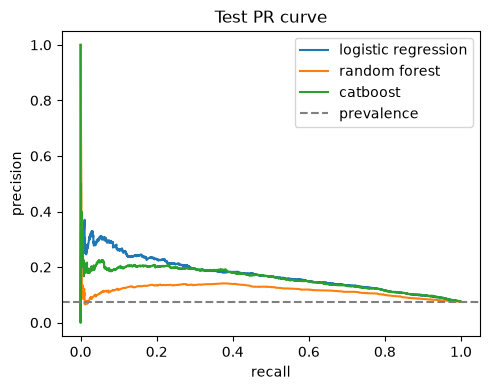

In [14]:
prec_lr, rec_lr, _ = precision_recall_curve(y_test, proba_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, proba_rf)
prec_cb, rec_cb, _ = precision_recall_curve(y_test, test_proba)

plt.figure(figsize=(5, 4))
plt.plot(rec_lr, prec_lr, label="logistic regression")
plt.plot(rec_rf, prec_rf, label="random forest")
plt.plot(rec_cb, prec_cb, label="catboost")
plt.axhline(y_test.mean(), linestyle="--", color="gray", label="prevalence")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Test PR curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/catboost_730d_pr_curve.png", dpi=100)
plt.show()

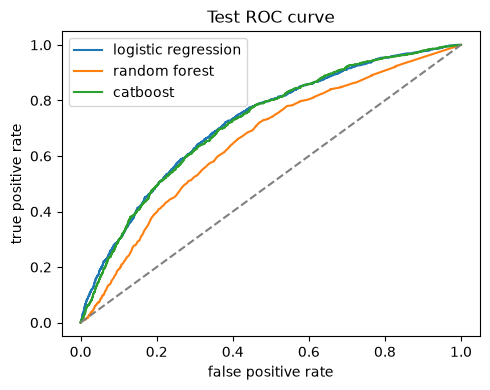

In [15]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
fpr_cb, tpr_cb, _ = roc_curve(y_test, test_proba)

plt.figure(figsize=(5, 4))
plt.plot(fpr_lr, tpr_lr, label="logistic regression")
plt.plot(fpr_rf, tpr_rf, label="random forest")
plt.plot(fpr_cb, tpr_cb, label="catboost")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Test ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/catboost_730d_roc_curve.png", dpi=100)
plt.show()

## CatBoost feature importance

Built-in CatBoost feature importance (PredictionValuesChange by default), not SHAP, not a causal effect. Just a descriptive summary of which features the model relies on most.

In [16]:
importances = model.get_feature_importance()
imp_df = pd.DataFrame({"feature": FEATURES, "importance": importances}).sort_values("importance", ascending=False).reset_index(drop=True)
imp_df

,feature,importance
0,days_since_previous_inspection,21.670252
1,n_inspections_seen_so_far,16.860774
2,prior_730d_total_infractions,14.877416
3,prior_365d_total_infractions,8.507305
4,prior_730d_n_inspections,6.475701
5,prev_non_pass,6.341114
6,prior_365d_n_inspections,5.123030
7,prev_total_infractions,4.331289
8,prev_minor,3.758696
9,prev_significant,3.288501


Similar to the Random Forest importance, `days_since_previous_inspection` and `n_inspections_seen_so_far` rank highest, with `prior_730d_total_infractions` close behind. The two tree models agree on roughly what matters, even though CatBoost achieves stronger predictive performance than Random Forest here.

## Save results

In [17]:
results = pd.DataFrame([
    {"model": "catboost", "feature_set": "previous inspection + 365-day + 730-day history (15 features)",
     "val_pr_auc": val_pr_auc, "val_roc_auc": val_roc_auc, "threshold": best_t,
     "test_pr_auc": test_pr_auc, "test_roc_auc": test_roc_auc,
     "test_precision": test_precision, "test_recall": test_recall,
     "test_f1": test_f1, "test_accuracy": test_accuracy,
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
])
results.to_csv("../outputs/catboost_730d_results.csv", index=False)
imp_df.to_csv("../outputs/catboost_730d_feature_importance.csv", index=False)
print("saved outputs/catboost_730d_results.csv")
print("saved outputs/catboost_730d_feature_importance.csv")

saved outputs/catboost_730d_results.csv
saved outputs/catboost_730d_feature_importance.csv


## Interpretation

On the same 15 longitudinal features and the same strict temporal split, CatBoost (test PR-AUC 0.159, ROC-AUC 0.717) clearly beat Random Forest (0.115, 0.652) but did not exceed Logistic Regression (0.173, 0.720), landing essentially level with it on ROC-AUC and F1 while being a bit lower on PR-AUC. Greater model flexibility did not translate into a clear improvement over the simpler linear model here. This is a comparison of which modelling approach best predicts the recorded DineSafe Non-Pass outcome from the same longitudinal information, not a claim about which model best captures true food safety, and no hyperparameter tuning was attempted for any of the three models.